# DVL-DeepONet for A-KIT DVL + IMU to Cartesian Velocity

This notebook predicts **Cartesian DVL velocity** from a time history of:

```text
4 DVL beams at 1 Hz + IMU accel/gyro interpolated to DVL time
```

Expected files:

| File | Meaning |
|---|---|
| `A-KIT/Data/Trajectory1/DVL_beams_traj_1.npy` | `(N,5)` = `[time, beam1, beam2, beam3, beam4]`, or `(N,4)` = beams only |
| `A-KIT/Data/Trajectory1/DVL_trajectory1.csv` | GT Cartesian DVL velocity columns |
| `A-KIT/AUV_IMU_npy/IMU_trajectory1.npy` | `(M,7)` = `[time, ax, ay, az, gx, gy, gz]` at about 100 Hz |

The pipeline is:

```text
DVL trajectory timestamps, 1 Hz
    -> load matching 100 Hz IMU trajectory
    -> interpolate IMU accel/gyro onto DVL timestamps
    -> concatenate [beam1..beam4, ax, ay, az, gx, gy, gz]
    -> windowed DVL+IMU history
    -> DVL-DeepONet velocity prediction
    -> compare against classical least-squares DVL velocity
```

Important notes:

- This uses IMU as **additional neural-network input features**.
- It does not yet perform full strapdown INS mechanization.
- IMU format is assumed to be `[time, ax, ay, az, gx, gy, gz]`.
- The main DeepONet branch uses IMU interpolated to DVL time; raw 100 Hz IMU windows are used only for the BeamsNetV1 baseline.


In [1]:
# ============================================================
# 0. Imports, setup, and reproducibility
# ============================================================

import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42

def set_seed(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    else:
        torch.backends.cudnn.benchmark = torch.cuda.is_available()

set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"
print("Using device:", DEVICE)

SAVE_DIR = Path("base_paper")
FIG_DIR = SAVE_DIR / "figures"
CKPT_DIR = SAVE_DIR / "checkpoints"
DATA_DIR = SAVE_DIR / "arrays"
for directory in (FIG_DIR, CKPT_DIR, DATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("Results folder:", SAVE_DIR.resolve())


Using device: cuda
Results folder: /home/asahoo/DVL/base_paper


In [2]:
# ============================================================
# 1. Load A-KIT DVL beams, high-rate IMU, and Cartesian velocity GT
# ============================================================
# Expected per trajectory:
#   A-KIT/Data/Trajectory1/DVL_beams_traj_1.npy
#   A-KIT/Data/Trajectory1/DVL_trajectory1.csv
#   A-KIT/AUV_IMU_npy/IMU_trajectory1.npy
#
# DVL_beams_traj_*.npy shape:
#   (N,5) = [time, beam1, beam2, beam3, beam4]
#   or (N,4) = [beam1, beam2, beam3, beam4]
#
# IMU_trajectory*.npy shape:
#   (M,7) = [time, ax, ay, az, gx, gy, gz]
#   usually 100 Hz, resampled here to DVL timestamps.
# ============================================================

import re
import pandas as pd

DATA_ROOT = Path("A-KIT/Data")
IMU_ROOT = Path("A-KIT/AUV_IMU_npy")
ALPHA_DEG = 20.0

TRAIN_TRAJECTORIES = None     # example: [1, 2, 3, 4, 5, 6, 7, 8]
VAL_TRAJECTORIES = None       # example: [9, 10]
TEST_TRAJECTORIES = None      # example: [11, 12, 13]

REQUIRED_VELOCITY_COLUMNS = ["DVL X [m/s]", "DVL Y [m/s]", "DVL Z [m/s]"]

# IMU_trajectory*.npy format is fixed by  data:
# [time, ax, ay, az, gx, gy, gz]
IMU_FEATURE_NAMES = ["ax", "ay", "az", "gx", "gy", "gz"]


IMU_RESAMPLE_MODE = "average"

BEAMSNET_IMU_T = 100           # Keep BeamsNetV1 parameter exactly as given: 100 IMU samples per DVL sample


def build_dvl_H(alpha_deg=20.0):
    """Build the 4x3 DVL beam geometry matrix used by the A-KIT beam generator."""
    alpha = np.deg2rad(alpha_deg)
    H = []
    for i in range(4):
        psi = np.deg2rad(45 + i * 90)
        H.append([
            np.cos(psi) * np.sin(alpha),
            np.sin(psi) * np.sin(alpha),
            np.cos(alpha),
        ])
    return np.asarray(H, dtype=np.float32)


def natural_traj_number(path):
    s = str(path)
    m = re.search(r"Trajectory(\d+)", s)
    if m:
        return int(m.group(1))
    m = re.search(r"trajectory(\d+)", s, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))
    m = re.search(r"traj_(\d+)", s)
    if m:
        return int(m.group(1))
    return 10**9


def find_imu_path(traj_num):
    candidates = [
        IMU_ROOT / f"IMU_trajectory{traj_num}.npy",
        IMU_ROOT / f"IMU_trajectory_{traj_num}.npy",
        IMU_ROOT / f"imu_trajectory{traj_num}.npy",
        IMU_ROOT / f"imu_trajectory_{traj_num}.npy",
    ]
    for path in candidates:
        if path.exists():
            return path
    matches = sorted(IMU_ROOT.glob(f"*trajectory*{traj_num}*.npy"), key=natural_traj_number)
    if matches:
        return matches[0]
    raise FileNotFoundError(f"No IMU file found for trajectory {traj_num} inside {IMU_ROOT.resolve()}")


def extract_fixed_imu_windows(imu_time_rel, imu_values, dvl_time_rel, window_len=BEAMSNET_IMU_T):
    # BeamsNetV1 baseline expects accel and gyro tensors shaped (N, 3, 100).
    acc_windows = np.zeros((len(dvl_time_rel), 3, window_len), dtype=np.float32)
    gyro_windows = np.zeros((len(dvl_time_rel), 3, window_len), dtype=np.float32)

    for i, t0 in enumerate(dvl_time_rel):
        start = int(np.searchsorted(imu_time_rel, t0, side="left"))
        end = start + window_len
        segment = imu_values[start:end]

        if len(segment) == 0:
            nearest = int(np.clip(np.searchsorted(imu_time_rel, t0), 0, len(imu_values) - 1))
            segment = imu_values[nearest:nearest + 1]
        if len(segment) < window_len:
            pad = np.repeat(segment[-1:], window_len - len(segment), axis=0)
            segment = np.vstack([segment, pad])

        acc_windows[i] = segment[:window_len, 0:3].T
        gyro_windows[i] = segment[:window_len, 3:6].T

    return acc_windows, gyro_windows


def load_and_resample_imu(traj_num, dvl_time_local):
    imu_path = find_imu_path(traj_num)
    imu = np.load(imu_path).astype(np.float32)
    if imu.ndim != 2 or imu.shape[1] != 7:
        raise ValueError(f"{imu_path} must have shape (M,7) = [time, ax, ay, az, gx, gy, gz], got {imu.shape}")

    imu_time = imu[:, 0]
    imu_values = imu[:, 1:7]
    if not np.isfinite(imu).all():
        raise ValueError(f"Non-finite values found in {imu_path}")
    if np.any(np.diff(imu_time) <= 0):
        raise ValueError(f"IMU time must be strictly increasing in {imu_path}")

    dvl_time_local = np.asarray(dvl_time_local, dtype=np.float32).reshape(-1)

    # Align if both sensors start from different absolute offsets but share the same relative clock.
    imu_time_rel = imu_time - imu_time[0]
    dvl_time_rel = dvl_time_local - dvl_time_local[0]

    if dvl_time_rel[0] < imu_time_rel[0] - 1e-6 or dvl_time_rel[-1] > imu_time_rel[-1] + 1e-6:
        print(
            f"Warning Trajectory{traj_num}: DVL time [{dvl_time_rel[0]:.3f}, {dvl_time_rel[-1]:.3f}] "
            f"extends beyond IMU time [{imu_time_rel[0]:.3f}, {imu_time_rel[-1]:.3f}]. Edge IMU values will be held."
        )



    if IMU_RESAMPLE_MODE != "average":
        raise ValueError(f"Unsupported IMU_RESAMPLE_MODE: {IMU_RESAMPLE_MODE}")
    
    imu_resampled = np.zeros((len(dvl_time_rel), imu_values.shape[1]), dtype=np.float32)
    
    for k in range(len(dvl_time_rel)):
    
        if k == 0:
            t_start = dvl_time_rel[0]
            t_end = dvl_time_rel[1]
        else:
            t_start = dvl_time_rel[k - 1]
            t_end = dvl_time_rel[k]
    
        mask = (imu_time_rel >= t_start) & (imu_time_rel < t_end)
    
        if np.any(mask):
            imu_resampled[k, :] = np.mean(imu_values[mask, :], axis=0)
        else:
            # fallback: use nearest IMU sample if no IMU sample is found in interval
            nearest_idx = np.argmin(np.abs(imu_time_rel - dvl_time_rel[k]))
            imu_resampled[k, :] = imu_values[nearest_idx, :]
    
    
    
    acc_windows, gyro_windows = extract_fixed_imu_windows(imu_time_rel, imu_values, dvl_time_rel)

    if len(imu_time) > 1:
        imu_dt = float(np.mean(np.diff(imu_time)))
        imu_fs = 1.0 / imu_dt if imu_dt > 0 else float("nan")
    else:
        imu_fs = float("nan")

    return imu_resampled, acc_windows, gyro_windows, imu_path, imu_fs


def load_akit_dvl_imu_velocity_data(data_root=DATA_ROOT, alpha_deg=20.0):
    data_root = Path(data_root)
    H_np = build_dvl_H(alpha_deg=alpha_deg)
    traj_dirs = sorted(data_root.glob("Trajectory*"), key=natural_traj_number)
    if len(traj_dirs) == 0:
        raise FileNotFoundError(f"No Trajectory* folders found inside: {data_root.resolve()}")
    if not IMU_ROOT.exists():
        raise FileNotFoundError(f"IMU_ROOT does not exist: {IMU_ROOT.resolve()}")

    all_t, all_beams, all_imu, all_acc_windows, all_gyro_windows, all_vel, all_traj_id, summaries = [], [], [], [], [], [], [], []
    global_time_offset = 0.0

    for traj_dir in traj_dirs:
        traj_num = natural_traj_number(traj_dir)
        beam_path = traj_dir / f"DVL_beams_traj_{traj_num}.npy"
        csv_path = traj_dir / f"DVL_trajectory{traj_num}.csv"

        if not beam_path.exists() or not csv_path.exists():
            missing = [path.name for path in (beam_path, csv_path) if not path.exists()]
            print(f"Skipping Trajectory{traj_num}: missing {missing}")
            continue

        beams_npy = np.load(beam_path).astype(np.float32)
        df = pd.read_csv(csv_path)
        missing_cols = [col for col in REQUIRED_VELOCITY_COLUMNS if col not in df.columns]
        if missing_cols:
            raise ValueError(f"{csv_path} missing required columns: {missing_cols}")

        if beams_npy.ndim != 2 or beams_npy.shape[1] not in (4, 5):
            raise ValueError(f"{beam_path} must have shape (N,4) or (N,5), got {beams_npy.shape}")

        if beams_npy.shape[1] == 5:
            t_local = beams_npy[:, 0:1]
            beams = beams_npy[:, 1:5]
        else:
            beams = beams_npy[:, 0:4]
            if "Time [s]" in df.columns:
                t_local = df["Time [s]"].to_numpy(dtype=np.float32).reshape(-1, 1)
            else:
                t_local = np.arange(len(beams), dtype=np.float32).reshape(-1, 1)

        vel = df[REQUIRED_VELOCITY_COLUMNS].to_numpy(dtype=np.float32)
        N = min(len(t_local), len(beams), len(vel))
        if N < 2:
            print(f"Skipping Trajectory{traj_num}: fewer than two aligned DVL samples")
            continue

        t_local = t_local[:N]
        beams = beams[:N]
        vel = vel[:N]

        imu_resampled, acc_windows, gyro_windows, imu_path, imu_fs = load_and_resample_imu(traj_num, t_local[:, 0])
        imu_resampled = imu_resampled[:N]
        acc_windows = acc_windows[:N]
        gyro_windows = gyro_windows[:N]

        if not np.isfinite(t_local).all() or not np.isfinite(beams).all() or not np.isfinite(vel).all() or not np.isfinite(imu_resampled).all():
            raise ValueError(f"Non-finite values found in Trajectory{traj_num}")

        dt = np.diff(t_local[:, 0])
        if np.any(dt <= 0):
            raise ValueError(f"Local DVL time must be strictly increasing in Trajectory{traj_num}")
        dt_est = float(np.median(dt))

        t_shifted = t_local - float(t_local[0, 0]) + global_time_offset
        global_time_offset = float(t_shifted[-1, 0] + dt_est)

        all_t.append(t_shifted.astype(np.float32))
        all_beams.append(beams.astype(np.float32))
        all_imu.append(imu_resampled.astype(np.float32))
        all_acc_windows.append(acc_windows.astype(np.float32))
        all_gyro_windows.append(gyro_windows.astype(np.float32))
        all_vel.append(vel.astype(np.float32))
        all_traj_id.append(np.full((N, 1), traj_num, dtype=np.int64))
        summaries.append((traj_num, N, dt_est, str(imu_path), imu_fs))
        print(f"Loaded Trajectory{traj_num}: DVL N={N}, DVL dt~{dt_est:.4g}s, IMU fs~{imu_fs:.2f}Hz")

    if len(all_t) == 0:
        raise FileNotFoundError("No valid trajectory pairs were loaded. Check the A-KIT output paths.")

    t = np.vstack(all_t).astype(np.float32)
    dvl_beams = np.vstack(all_beams).astype(np.float32)
    imu_data = np.vstack(all_imu).astype(np.float32)
    imu_acc_windows = np.vstack(all_acc_windows).astype(np.float32)
    imu_gyro_windows = np.vstack(all_gyro_windows).astype(np.float32)
    dvl_cart_gt = np.vstack(all_vel).astype(np.float32)
    traj_id = np.vstack(all_traj_id).astype(np.int64)
    return t, dvl_beams, imu_data, imu_acc_windows, imu_gyro_windows, dvl_cart_gt, H_np, traj_id, summaries


def validate_arrays(t, dvl_beams, imu_data, dvl_cart_gt, H_np, traj_id):
    t = np.asarray(t, dtype=np.float32)
    if t.ndim == 1:
        t = t[:, None]
    dvl_beams = np.asarray(dvl_beams, dtype=np.float32)
    imu_data = np.asarray(imu_data, dtype=np.float32)
    dvl_cart_gt = np.asarray(dvl_cart_gt, dtype=np.float32)
    H_np = np.asarray(H_np, dtype=np.float32)
    traj_id = np.asarray(traj_id, dtype=np.int64)
    if traj_id.ndim == 1:
        traj_id = traj_id[:, None]

    if t.ndim != 2 or t.shape[1] != 1:
        raise ValueError(f"time must have shape (N,) or (N,1); got {t.shape}")
    if dvl_beams.ndim != 2 or dvl_beams.shape[1] != 4:
        raise ValueError(f"dvl_beams must have shape (N,4); got {dvl_beams.shape}")
    if imu_data.ndim != 2 or imu_data.shape[1] != 6:
        raise ValueError(f"imu_data must have shape (N,6) = accel xyz + gyro xyz; got {imu_data.shape}")
    if dvl_cart_gt.ndim != 2 or dvl_cart_gt.shape[1] != 3:
        raise ValueError(f"dvl_cartesian_gt must have shape (N,3); got {dvl_cart_gt.shape}")
    if H_np.shape != (4, 3):
        raise ValueError(f"H_dvl must have shape (4,3); got {H_np.shape}")
    if not (len(t) == len(dvl_beams) == len(imu_data) == len(dvl_cart_gt) == len(traj_id)):
        raise ValueError("N mismatch between time, beams, IMU, Cartesian velocity, and trajectory IDs")
    if np.any(np.diff(t[:, 0]) <= 0):
        raise ValueError("global time values must be strictly increasing")

    arrays = {"time": t, "dvl_beams": dvl_beams, "imu_data": imu_data, "dvl_cartesian_gt": dvl_cart_gt, "H": H_np}
    bad = [name for name, arr in arrays.items() if not np.isfinite(arr).all()]
    if bad:
        raise ValueError(f"Non-finite values found in: {bad}")
    return t, dvl_beams, imu_data, dvl_cart_gt, H_np, traj_id


t, dvl_beams, imu_data, imu_acc_windows, imu_gyro_windows, dvl_cart_gt, H_np, traj_id, traj_summaries = load_akit_dvl_imu_velocity_data(DATA_ROOT, ALPHA_DEG)
t, dvl_beams, imu_data, dvl_cart_gt, H_np, traj_id = validate_arrays(t, dvl_beams, imu_data, dvl_cart_gt, H_np, traj_id)
VEL_DIM = dvl_cart_gt.shape[1]
INPUT_DIM = dvl_beams.shape[1] + imu_data.shape[1]

DATA_DIR.mkdir(parents=True, exist_ok=True)
np.save(DATA_DIR / "akit_time_global.npy", t)
np.save(DATA_DIR / "akit_dvl_beams.npy", dvl_beams)
np.save(DATA_DIR / "akit_imu_resampled_to_dvl.npy", imu_data)
np.save(DATA_DIR / "akit_imu_acc_windows.npy", imu_acc_windows)
np.save(DATA_DIR / "akit_imu_gyro_windows.npy", imu_gyro_windows)
np.save(DATA_DIR / "akit_dvl_cartesian_gt.npy", dvl_cart_gt)
np.save(DATA_DIR / "akit_H_dvl.npy", H_np)
np.save(DATA_DIR / "akit_traj_id.npy", traj_id)

print("\nFinal connected dataset")
print("time shape            :", t.shape)
print("dvl_beams shape       :", dvl_beams.shape)
print("imu_data shape        :", imu_data.shape, IMU_FEATURE_NAMES)
print("imu_acc_windows shape :", imu_acc_windows.shape)
print("imu_gyro_windows shape:", imu_gyro_windows.shape)
print("dvl_cartesian_gt shape:", dvl_cart_gt.shape)
print("H shape               :", H_np.shape)
print("VEL_DIM               :", VEL_DIM)
print("INPUT_DIM             :", INPUT_DIM, "= 4 DVL beams + 6 interpolated IMU values") #to check
print("Trajectory IDs        :", np.unique(traj_id[:, 0]).astype(int))


Loaded Trajectory1: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory2: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory3: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory4: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory5: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory6: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory7: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory8: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory9: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory10: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory11: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory12: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz
Loaded Trajectory13: DVL N=400, DVL dt~1.003s, IMU fs~100.00Hz

Final connected dataset
time shape            : (5200, 1)
dvl_beams shape       : (5200, 4)
imu_data shape        : (5200, 6) ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
imu_acc_windows shape : (5

In [3]:
# ============================================================
# 2. Normalization, trajectory-aware split, and LS baseline
# ============================================================

WINDOW =  2 
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

# Three different trajectory-level train/val/test splits for cross-validation.

USE_THREE_FOLD_CV = True
CV_FOLD = 2  # choose 1 or 2 or 3 for paper
N_CV_FOLDS = 5


def safe_std(x, axis=0, eps=1e-8):
    return np.maximum(np.std(x, axis=axis, keepdims=True), eps).astype(np.float32)


def build_three_cv_splits(unique_ids, train_ratio=0.70, val_ratio=0.15, n_folds=3):
    unique_ids = np.asarray(sorted(unique_ids), dtype=np.int64)
    n_total = len(unique_ids)
    if n_total < 6:
        raise ValueError("Need at least six trajectories for useful 3-fold train/val/test splits")

    n_train = max(1, int(round(n_total * train_ratio)))
    n_val = max(1, int(round(n_total * val_ratio)))
    if n_train + n_val >= n_total:
        n_train = max(1, n_total - 2)
        n_val = 1

    splits = []
    for fold in range(n_folds):
        offset = int(round(fold * n_total / n_folds))
        rolled = np.roll(unique_ids, -offset)
        train_ids = np.asarray(sorted(rolled[:n_train]), dtype=np.int64)
        val_ids = np.asarray(sorted(rolled[n_train:n_train + n_val]), dtype=np.int64)
        test_ids = np.asarray(sorted(rolled[n_train + n_val:]), dtype=np.int64)
        splits.append({"train": train_ids, "val": val_ids, "test": test_ids})
    return splits


def split_trajectory_ids(unique_ids, train_ratio=0.70, val_ratio=0.15):
    unique_ids = np.asarray(sorted(unique_ids), dtype=np.int64)

    # Manual lists override the automatic CV split.
    if TRAIN_TRAJECTORIES is not None or VAL_TRAJECTORIES is not None or TEST_TRAJECTORIES is not None:
        train_ids = np.asarray([] if TRAIN_TRAJECTORIES is None else TRAIN_TRAJECTORIES, dtype=np.int64)
        val_ids = np.asarray([] if VAL_TRAJECTORIES is None else VAL_TRAJECTORIES, dtype=np.int64)
        test_ids = np.asarray([] if TEST_TRAJECTORIES is None else TEST_TRAJECTORIES, dtype=np.int64)
        cv_splits = None
    elif USE_THREE_FOLD_CV:
        cv_splits = build_three_cv_splits(unique_ids, train_ratio, val_ratio, N_CV_FOLDS)
        if CV_FOLD < 0 or CV_FOLD >= len(cv_splits):
            raise ValueError(f"CV_FOLD must be one of 0, 1, 2; got {CV_FOLD}")
        selected = cv_splits[CV_FOLD]
        train_ids = selected["train"]
        val_ids = selected["val"]
        test_ids = selected["test"]
    else:
        cv_splits = None
        n_total = len(unique_ids)
        if n_total < 3:
            raise ValueError("Need at least three trajectories for trajectory-level train/val/test split")
        n_train = max(1, int(round(n_total * train_ratio)))
        n_val = max(1, int(round(n_total * val_ratio)))
        if n_train + n_val >= n_total:
            n_train = max(1, n_total - 2)
            n_val = 1
        train_ids = unique_ids[:n_train]
        val_ids = unique_ids[n_train:n_train + n_val]
        test_ids = unique_ids[n_train + n_val:]

    assigned = np.concatenate([train_ids, val_ids, test_ids])
    if len(assigned) != len(np.unique(assigned)):
        raise ValueError("Train/val/test trajectory lists overlap")
    missing = set(unique_ids.tolist()) - set(assigned.tolist())
    if missing:
        print("Unused trajectory IDs:", sorted(missing))
    if len(train_ids) == 0 or len(val_ids) == 0 or len(test_ids) == 0:
        raise ValueError("Train, validation, and test trajectory sets must all be non-empty")
    return train_ids, val_ids, test_ids, cv_splits


def indices_for_trajectories(ids):
    ids = np.asarray(ids, dtype=np.int64)
    return np.flatnonzero(np.isin(traj_id[:, 0], ids))


def beams_to_cartesian_ls(beams, H, vel_dim):
    v3 = beams @ np.linalg.pinv(H).T
    return v3[:, :vel_dim].astype(np.float32)


N = len(t)
unique_traj_ids = np.unique(traj_id[:, 0])
train_traj_ids, val_traj_ids, test_traj_ids, cv_splits = split_trajectory_ids(unique_traj_ids, TRAIN_RATIO, VAL_RATIO)
idx_train = indices_for_trajectories(train_traj_ids)
idx_val = indices_for_trajectories(val_traj_ids)
idx_test = indices_for_trajectories(test_traj_ids)

dvl_cart_ls = beams_to_cartesian_ls(dvl_beams, H_np, VEL_DIM)
raw_features = np.concatenate([dvl_beams, imu_data], axis=1).astype(np.float32)

# Compute normalization statistics from training samples only.
t_mean = t[idx_train].mean(axis=0, keepdims=True).astype(np.float32)
t_std = safe_std(t[idx_train], axis=0)
feature_mean = raw_features[idx_train].mean(axis=0, keepdims=True).astype(np.float32)
feature_std = safe_std(raw_features[idx_train], axis=0)
vel_mean = dvl_cart_gt[idx_train].mean(axis=0, keepdims=True).astype(np.float32)
vel_std = safe_std(dvl_cart_gt[idx_train], axis=0)

t_n = (t - t_mean) / t_std
features_n = (raw_features - feature_mean) / feature_std
vel_gt_n = (dvl_cart_gt - vel_mean) / vel_std

if cv_splits is not None:
    print("Available 3-fold trajectory splits:")
    for fold, split in enumerate(cv_splits):
        marker = " <== active" if fold == CV_FOLD else ""
        print(
            f"Fold {fold}: "
            f"train={split['train'].tolist()} | "
            f"val={split['val'].tolist()} | "
            f"test={split['test'].tolist()}" + marker
        )

print("Train trajectory IDs:", train_traj_ids)
print("Val trajectory IDs  :", val_traj_ids)
print("Test trajectory IDs :", test_traj_ids)
print("Train samples:", len(idx_train))
print("Val samples  :", len(idx_val))
print("Test samples :", len(idx_test))
print("Interpolated DeepONet feature shape:", raw_features.shape)
print("Feature mean shape:", feature_mean.shape)
print("Feature std shape :", feature_std.shape)
print("Velocity mean:", vel_mean)
print("Velocity std :", vel_std)

ls_err = np.linalg.norm(dvl_cart_ls - dvl_cart_gt[:, :VEL_DIM], axis=1)
print("LS sanity RMSE [m/s]:", float(np.sqrt(np.mean(ls_err ** 2))))
print("LS sanity mean error [m/s]:", float(np.mean(ls_err)))


Available 3-fold trajectory splits:
Fold 0: train=[1, 2, 3, 4, 5, 6, 7, 8, 9] | val=[10, 11] | test=[12, 13]
Fold 1: train=[4, 5, 6, 7, 8, 9, 10, 11, 12] | val=[1, 13] | test=[2, 3]
Fold 2: train=[1, 6, 7, 8, 9, 10, 11, 12, 13] | val=[2, 3] | test=[4, 5] <== active
Fold 3: train=[1, 2, 3, 4, 9, 10, 11, 12, 13] | val=[5, 6] | test=[7, 8]
Fold 4: train=[1, 2, 3, 4, 5, 6, 11, 12, 13] | val=[7, 8] | test=[9, 10]
Train trajectory IDs: [ 1  6  7  8  9 10 11 12 13]
Val trajectory IDs  : [2 3]
Test trajectory IDs : [4 5]
Train samples: 3600
Val samples  : 800
Test samples : 800
Interpolated DeepONet feature shape: (5200, 10)
Feature mean shape: (1, 10)
Feature std shape : (1, 10)
Velocity mean: [[1.9608576e+00 8.1083912e-04 1.2987200e-03]]
Velocity std : [[0.43833315 0.2987743  0.07166067]]
LS sanity RMSE [m/s]: 0.1248529851436615
LS sanity mean error [m/s]: 0.1118013858795166


In [4]:
# ============================================================
# 3. Dataset
# ============================================================

class DVLIMUCartesianVelocityDataset(Dataset):
    def __init__(self, indices, window):
        self.window = int(window)
        indices = np.asarray(indices, dtype=np.int64)

        valid = []
        for i in indices:
            s = i - self.window + 1
            if s < 0:
                continue
            if np.all(traj_id[s:i + 1, 0] == traj_id[i, 0]):
                valid.append(i)
        self.valid_indices = np.asarray(valid, dtype=np.int64)
        if len(self.valid_indices) == 0:
            raise ValueError("No valid samples for this split; reduce WINDOW or adjust the split")

        self.features_n = torch.from_numpy(features_n.astype(np.float32))
        self.t_n = torch.from_numpy(t_n.astype(np.float32))
        self.vel_gt_n = torch.from_numpy(vel_gt_n.astype(np.float32))
        self.beams_raw = torch.from_numpy(dvl_beams.astype(np.float32))
        self.t_raw = torch.from_numpy(t.astype(np.float32))
        self.traj_id = torch.from_numpy(traj_id.astype(np.int64))

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, item):
        i = int(self.valid_indices[item])
        s = i - self.window + 1
        e = i + 1
        return {
            "branch": self.features_n[s:e],
            "trunk": self.t_n[i],
            "vel": self.vel_gt_n[i],
            "beam_raw": self.beams_raw[i],
            "t_raw": self.t_raw[i],
            "traj_id": self.traj_id[i, 0],
            "index": torch.tensor(i, dtype=torch.long),
        }


BATCH_SIZE = 128
NUM_WORKERS = 0

generator = torch.Generator()
generator.manual_seed(SEED)
loader_kwargs = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

train_ds = DVLIMUCartesianVelocityDataset(idx_train, WINDOW)
val_ds = DVLIMUCartesianVelocityDataset(idx_val, WINDOW)
test_ds = DVLIMUCartesianVelocityDataset(idx_test, WINDOW)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=generator, **loader_kwargs)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print("Train dataset:", len(train_ds))
print("Val dataset  :", len(val_ds))
print("Test dataset :", len(test_ds))

sample = train_ds[0]
for key, value in sample.items():
    print(key, value.shape if hasattr(value, "shape") else value)


Train dataset: 3591
Val dataset  : 798
Test dataset : 798
branch torch.Size([2, 10])
trunk torch.Size([1])
vel torch.Size([3])
beam_raw torch.Size([4])
t_raw torch.Size([1])
traj_id torch.Size([])
index torch.Size([])


In [5]:
# ============================================================
# 4. LS-DeepONet DVL+interpolated-IMU velocity model
# ============================================================


LATENT_DIM=32 #128,32=0.105


class BranchCNN(nn.Module):
    def __init__(self, window, input_dim, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(input_dim, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.SiLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.SiLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.SiLU(),
            nn.Flatten(),
            nn.Linear(64 * window, latent_dim),
            nn.SiLU(),
        )

    def forward(self, branch):
       
        # Conv1d expects (B, channels, length).
        return self.net(branch.permute(0, 2, 1))


class TrunkMLP(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 128), #32-128
            nn.Tanh(),
            nn.Linear(128, latent_dim),
            nn.Tanh(),
        )

    def forward(self, trunk):
        return self.net(trunk)


class LSDeepONetDVLIMUVelocity(nn.Module):
    def __init__(self, window, input_dim, vel_dim, latent_dim=LATENT_DIM):
        super().__init__()
        self.vel_dim = vel_dim
        self.branch = BranchCNN(window, input_dim, latent_dim)
        self.trunk = TrunkMLP(latent_dim)
        self.head = nn.Sequential(
            nn.LayerNorm(latent_dim),
            nn.Linear(latent_dim, 128),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.SiLU(),
            nn.Linear(64, vel_dim),
        )

    def forward(self, branch, trunk):
        z = self.branch(branch) * self.trunk(trunk)
        return self.head(z)


model = LSDeepONetDVLIMUVelocity(WINDOW, INPUT_DIM, VEL_DIM, latent_dim=LATENT_DIM).to(DEVICE) 
print(model)
print("Parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


LSDeepONetDVLIMUVelocity(
  (branch): BranchCNN(
    (net): Sequential(
      (0): Conv1d(10, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU()
      (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): SiLU()
      (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (7): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): SiLU()
      (9): Flatten(start_dim=1, end_dim=-1)
      (10): Linear(in_features=128, out_features=32, bias=True)
      (11): SiLU()
    )
  )
  (trunk): TrunkMLP(
    (net): Sequential(
      (0): Linear(in_features=1, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=128, bias=True)
      (3): Tanh()
      (4): Linear(in_features=128, out_features

In [6]:
# ============================================================
# 5. Loss functions
# ============================================================

vel_mean_t = torch.as_tensor(vel_mean, dtype=torch.float32, device=DEVICE)
vel_std_t = torch.as_tensor(vel_std, dtype=torch.float32, device=DEVICE)
H_t = torch.as_tensor(H_np, dtype=torch.float32, device=DEVICE)


def denorm_vel(vel_hat_n):
    return vel_hat_n * vel_std_t + vel_mean_t


def velocity_supervised_loss(vel_hat_n, vel_gt_n_batch):
    return torch.mean((vel_hat_n - vel_gt_n_batch) ** 2)


def beam_consistency_loss(vel_hat_n, beam_raw):
    # Enforces H @ v_cartesian ~= raw beams.
    vel_hat = denorm_vel(vel_hat_n)
    vel_3d = vel_hat[:, :3]
    beam_pred = vel_3d @ H_t.T
    return torch.mean((beam_pred - beam_raw) ** 2)


In [7]:
# ============================================================
# 6. Training setup
# ============================================================

EPOCHS = 50
LR = 1e-3
PATIENCE = 20
MIN_DELTA = 1e-6

# Main target is Cartesian velocity. Beam consistency is a physical regularizer.
LAMBDA_VEL = 1.0
LAMBDA_BEAM = 0.1

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=10,
    factor=0.5,
)

history = {
    "train_total": [], "val_total": [],
    "train_vel": [], "val_vel": [],
    "train_beam": [], "val_beam": [],
}


In [ ]:
# ============================================================
# 7. Training loop
# ============================================================


def to_device(batch):
    return {key: value.to(DEVICE, non_blocking=PIN_MEMORY) for key, value in batch.items()}


def run_epoch(loader, train=True):
    model.train(train)
    sums = {"total": 0.0, "vel": 0.0, "beam": 0.0}
    count = 0

    for batch in loader:
        batch = to_device(batch)
        branch = batch["branch"]
        trunk = batch["trunk"]
        vel_gt_n_batch = batch["vel"]
        beam_raw = batch["beam_raw"]

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            vel_hat_n = model(branch, trunk)
            L_vel = velocity_supervised_loss(vel_hat_n, vel_gt_n_batch)
            L_beam = beam_consistency_loss(vel_hat_n, beam_raw)
            L_total = LAMBDA_VEL * L_vel + LAMBDA_BEAM * L_beam
            #L_total =  LAMBDA_VEL * L_vel 

            if train:
                L_total.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        bs = branch.shape[0]
        sums["total"] += float(L_total.detach().cpu()) * bs
        sums["vel"] += float(L_vel.detach().cpu()) * bs
        sums["beam"] += float(L_beam.detach().cpu()) * bs
        count += bs

    return {key: value / max(count, 1) for key, value in sums.items()}


best_val = float("inf")
best_path = CKPT_DIR / "best_ls_deeponet_velocity.pt"
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_m = run_epoch(train_loader, train=True)
    val_m = run_epoch(val_loader, train=False)
    scheduler.step(val_m["total"])

    for key in ["total", "vel", "beam"]:
        history[f"train_{key}"].append(train_m[key])
        history[f"val_{key}"].append(val_m[key])

    improved = val_m["total"] < best_val - MIN_DELTA
    if improved:
        best_val = val_m["total"]
        epochs_without_improvement = 0
        torch.save({
            "model_state": model.state_dict(),
            "history": history,
            "H": H_np,
            "split": {
                "train_trajectories": train_traj_ids.tolist(),
                "val_trajectories": val_traj_ids.tolist(),
                "test_trajectories": test_traj_ids.tolist(),
                "cv_fold": CV_FOLD if USE_THREE_FOLD_CV else None,
            },
            "config": {
                "seed": SEED,
                "window": WINDOW,
                "input_dim": INPUT_DIM,
                "vel_dim": VEL_DIM,
                "batch_size": BATCH_SIZE,
                "epochs_completed": epoch,
                "alpha_deg": ALPHA_DEG,
                "loss_weights": {
                    "vel": LAMBDA_VEL,
                    "beam": LAMBDA_BEAM,
                },
            },
            "stats": {
                "t_mean": t_mean, "t_std": t_std,
                "feature_mean": feature_mean, "feature_std": feature_std,
                "vel_mean": vel_mean, "vel_std": vel_std,
            },
        }, best_path)
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0 or improved:
        print(
            f"Epoch {epoch:04d} | "
            f"Train={train_m['total']:.4e} | Val={val_m['total']:.4e} | "
            f"Vel={val_m['vel']:.2e} | Beam={val_m['beam']:.2e} | "
            f"LR={optimizer.param_groups[0]['lr']:.1e}"
        )

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}; best validation loss was {best_val:.4e}.")
        break

print("Best validation loss:", best_val)
print("Saved checkpoint:", best_path)




In [ ]:
# ============================================================
# 8. Prediction helpers and full prediction
# ============================================================

ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()


def predict_dataset(dataset, batch_size=512):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, **loader_kwargs)
    pred_vel_list, t_list, idx_list, traj_list = [], [], [], []

    with torch.no_grad():
        for batch in loader:
            batch = to_device(batch)
            vel_hat_n = model(batch["branch"], batch["trunk"])
            pred_vel_list.append(denorm_vel(vel_hat_n).cpu().numpy())
            t_list.append(batch["t_raw"].cpu().numpy())
            idx_list.append(batch["index"].cpu().numpy())
            traj_list.append(batch["traj_id"].cpu().numpy())

    pred_vel = np.concatenate(pred_vel_list, axis=0)
    t_out = np.concatenate(t_list, axis=0)[:, 0]
    idx_out = np.concatenate(idx_list, axis=0)
    traj_out = np.concatenate(traj_list, axis=0)
    return pred_vel, t_out, idx_out, traj_out


full_ds = DVLIMUCartesianVelocityDataset(np.arange(N), WINDOW)
pred_vel_nn, t_aligned, valid_idx, traj_aligned = predict_dataset(full_ds)
vel_gt_aligned = dvl_cart_gt[valid_idx, :VEL_DIM]
vel_ls_aligned = dvl_cart_ls[valid_idx, :VEL_DIM]

split_predictions = {}
for split_name, dataset in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    pred, t_split, idx_split, traj_split = predict_dataset(dataset)
    split_predictions[split_name] = {
        "pred": pred,
        "time": t_split,
        "index": idx_split,
        "traj_id": traj_split,
        "gt": dvl_cart_gt[idx_split, :VEL_DIM],
        "ls": dvl_cart_ls[idx_split, :VEL_DIM],
    }

np.save(DATA_DIR / "pred_vel_nn.npy", pred_vel_nn)
np.save(DATA_DIR / "vel_gt_aligned.npy", vel_gt_aligned)
np.save(DATA_DIR / "vel_ls_aligned.npy", vel_ls_aligned)
np.save(DATA_DIR / "t_aligned.npy", t_aligned)
np.save(DATA_DIR / "traj_aligned.npy", traj_aligned)

print("pred_vel_nn    :", pred_vel_nn.shape)
print("vel_gt_aligned :", vel_gt_aligned.shape)
print("vel_ls_aligned :", vel_ls_aligned.shape)



In [ ]:
# # ============================================================
# # 10. BeamsNetV1 baseline from reference code
# # ============================================================
# # This baseline keeps the architecture parameters from the provided code:
# #   Conv1d(in_channels=3, out_channels=6, kernel_size=2, stride=1)
# #   Linear(1188, 512) -> 256 -> 64 -> 2
# #   Dropout p=0.2
# #   FC_output Linear(4 + 2, 3)
# #   batch_size = 4

# class BeamsNetV1(nn.Module):
#     def __init__(self):
#         super(BeamsNetV1, self).__init__()
#         self.conv_layer = nn.Sequential(
#             nn.Conv1d(in_channels=3, out_channels=6, kernel_size=2, stride=1),
#             nn.Tanh(),
#         )
#         self.ConvToFc = nn.Sequential(
#             nn.Linear(1188, 512),
#             nn.ReLU(),
#             nn.Linear(512, 256),
#             nn.ReLU(),
#             nn.Linear(256, 64),
#             nn.ReLU(),
#             nn.Linear(64, 2),
#             nn.ReLU(),
#         )
#         self.FC_output = nn.Sequential(
#             nn.Linear(4 + 2, 3),
#         )
#         self.initialize_weights()

#     def forward(self, x1, x2, y):
#         x1 = self.conv_layer(x1)
#         x2 = self.conv_layer(x2)
#         x1 = torch.flatten(x1, 1)
#         x2 = torch.flatten(x2, 1)
#         x = torch.column_stack((x1, x2))
#         x = F.dropout(x, p=0.2)
#         x = self.ConvToFc(x)
#         x = torch.column_stack((x, y))
#         x = self.FC_output(x)
#         return x

#     def initialize_weights(self):
#         for m in self.modules():
#             if isinstance(m, nn.Conv1d):
#                 nn.init.kaiming_uniform_(m.weight)
#             if isinstance(m, nn.Linear):
#                 nn.init.kaiming_uniform_(m.weight)


# class BeamsNetDataset(Dataset):
#     def __init__(self, indices):
#         self.indices = np.asarray(indices, dtype=np.int64)
#         self.acc = torch.from_numpy(imu_acc_windows[self.indices].astype(np.float32))
#         self.gyro = torch.from_numpy(imu_gyro_windows[self.indices].astype(np.float32))
#         self.beams = torch.from_numpy(dvl_beams[self.indices].astype(np.float32))
#         self.target = torch.from_numpy(dvl_cart_gt[self.indices].astype(np.float32))

#     def __len__(self):
#         return len(self.indices)

#     def __getitem__(self, item):
#         return self.acc[item], self.gyro[item], self.beams[item], self.target[item]


# BEAMSNET_BATCH_SIZE = 4
# BEAMSNET_EPOCHS = 50 
# BEAMSNET_LR = 1e-3
# BEAMSNET_PATIENCE = 20

# beamsnet_train_ds = BeamsNetDataset(train_ds.valid_indices)
# beamsnet_val_ds = BeamsNetDataset(val_ds.valid_indices)
# beamsnet_test_ds = BeamsNetDataset(test_ds.valid_indices)

# beamsnet_train_loader = DataLoader(beamsnet_train_ds, batch_size=BEAMSNET_BATCH_SIZE, shuffle=True, generator=generator, **loader_kwargs)
# beamsnet_val_loader = DataLoader(beamsnet_val_ds, batch_size=BEAMSNET_BATCH_SIZE, shuffle=False, **loader_kwargs)
# beamsnet_test_loader = DataLoader(beamsnet_test_ds, batch_size=BEAMSNET_BATCH_SIZE, shuffle=False, **loader_kwargs)

# beamsnet_model = BeamsNetV1().to(DEVICE)
# beamsnet_optimizer = torch.optim.Adam(beamsnet_model.parameters(), lr=BEAMSNET_LR)
# beamsnet_loss_fn = nn.MSELoss()


# def run_beamsnet_epoch(loader, train=True):
#     beamsnet_model.train(train)
#     total = 0.0
#     count = 0
#     for acc_batch, gyro_batch, beam_batch, target_batch in loader:
#         acc_batch = acc_batch.to(DEVICE, non_blocking=PIN_MEMORY)
#         gyro_batch = gyro_batch.to(DEVICE, non_blocking=PIN_MEMORY)
#         beam_batch = beam_batch.to(DEVICE, non_blocking=PIN_MEMORY)
#         target_batch = target_batch.to(DEVICE, non_blocking=PIN_MEMORY)

#         if train:
#             beamsnet_optimizer.zero_grad(set_to_none=True)

#         with torch.set_grad_enabled(train):
#             pred = beamsnet_model(acc_batch, gyro_batch, beam_batch)
#             loss = beamsnet_loss_fn(pred, target_batch)
#             if train:
#                 loss.backward()
#                 beamsnet_optimizer.step()

#         bs = target_batch.shape[0]
#         total += float(loss.detach().cpu()) * bs
#         count += bs
#     return total / max(count, 1)


# best_beamsnet_val = float("inf")
# beamsnet_epochs_without_improvement = 0
# beamsnet_best_path = CKPT_DIR / "best_beamsnet_v1.pt"

# for epoch in range(1, BEAMSNET_EPOCHS + 1):
#     train_loss = run_beamsnet_epoch(beamsnet_train_loader, train=True)
#     val_loss = run_beamsnet_epoch(beamsnet_val_loader, train=False)

#     if val_loss < best_beamsnet_val - MIN_DELTA:
#         best_beamsnet_val = val_loss
#         beamsnet_epochs_without_improvement = 0
#         torch.save({
#             "model_state": beamsnet_model.state_dict(),
#             "config": {
#                 "batch_size": BEAMSNET_BATCH_SIZE,
#                 "epochs_completed": epoch,
#                 "learning_rate": BEAMSNET_LR,
#                 "imu_window": BEAMSNET_IMU_T,
#             },
#         }, beamsnet_best_path)
#     else:
#         beamsnet_epochs_without_improvement += 1

#     if epoch == 1 or epoch % 10 == 0 or beamsnet_epochs_without_improvement == 0:
#         print(f"BeamsNetV1 epoch {epoch:04d} | Train={train_loss:.4e} | Val={val_loss:.4e}")

#     if beamsnet_epochs_without_improvement >= BEAMSNET_PATIENCE:
#         print(f"BeamsNetV1 early stopping at epoch {epoch}; best val loss was {best_beamsnet_val:.4e}.")
#         break

# beamsnet_ckpt = torch.load(beamsnet_best_path, map_location=DEVICE, weights_only=False)
# beamsnet_model.load_state_dict(beamsnet_ckpt["model_state"])
# beamsnet_model.eval()


# def predict_beamsnet(indices, batch_size=BEAMSNET_BATCH_SIZE):
#     ds = BeamsNetDataset(indices)
#     loader = DataLoader(ds, batch_size=batch_size, shuffle=False, **loader_kwargs)
#     preds = []
#     with torch.no_grad():
#         for acc_batch, gyro_batch, beam_batch, _ in loader:
#             acc_batch = acc_batch.to(DEVICE, non_blocking=PIN_MEMORY)
#             gyro_batch = gyro_batch.to(DEVICE, non_blocking=PIN_MEMORY)
#             beam_batch = beam_batch.to(DEVICE, non_blocking=PIN_MEMORY)
#             preds.append(beamsnet_model(acc_batch, gyro_batch, beam_batch).cpu().numpy())
#     return np.concatenate(preds, axis=0)


# for split_name, values in split_predictions.items():
#     values["beamsnet"] = predict_beamsnet(values["index"])

# beamsnet_full_aligned = predict_beamsnet(valid_idx)
# np.save(DATA_DIR / "beamsnet_v1_aligned.npy", beamsnet_full_aligned)
# print("beamsnet_full_aligned:", beamsnet_full_aligned.shape)


In [ ]:


# ============================================================
# 10. Velocity metrics
# ============================================================

def compute_velocity_metrics(pred, gt):
    err_vec = pred - gt
    err_norm = np.linalg.norm(err_vec, axis=1)

    # Existing metrics
    per_axis_rmse = np.sqrt(np.mean(err_vec ** 2, axis=0))

    # R² for each axis
    r2_axes = []
    vaf_axes = []

    for i in range(gt.shape[1]):
        y_true = gt[:, i]
        y_pred = pred[:, i]

        # R²
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

        r2 = 1.0 - ss_res / (ss_tot + 1e-12)

        # VAF (%)
        vaf = (
            1.0
            - np.var(y_true - y_pred)
            / (np.var(y_true) + 1e-12)
        ) * 100.0

        r2_axes.append(float(r2))
        vaf_axes.append(float(vaf))

    return {
        "RMSE_vector": float(np.sqrt(np.mean(np.sum(err_vec ** 2, axis=1)))),
        "MAE_vector": float(np.mean(err_norm)),
        "Median_error_vector": float(np.median(err_norm)),
        "Max_error_vector": float(np.max(err_norm)),
        "RMSE_axes": [float(x) for x in per_axis_rmse],

        # New metrics
        "R2_axes": r2_axes,
        "R2_mean": float(np.mean(r2_axes)),

        "VAF_axes_percent": vaf_axes,
        "VAF_mean_percent": float(np.mean(vaf_axes)),
    }
def format_metric_value(value, decimals=3):
    if isinstance(value, list):
        return "[" + ", ".join(f"{x:.{decimals}f}" for x in value) + "]"
    return f"{value:.{decimals}f}"


metrics = {}
for split_name, values in split_predictions.items():
    metrics[split_name] = {
        "LS_DeepONet_velocity": compute_velocity_metrics(values["pred"], values["gt"]),
        #"LS_DeepONet_velocity_KF": compute_velocity_metrics(values["kf"], values["gt"]),
        #"BeamsNetV1_baseline": compute_velocity_metrics(values["beamsnet"], values["gt"]),
        "Classical_LS_velocity": compute_velocity_metrics(values["ls"], values["gt"]),
    }



for split_name, split_metrics in metrics.items():
    print(f"========== {split_name.upper()} ==========")
    for model_name, model_metrics in split_metrics.items():
        print(model_name)
        for key, value in model_metrics.items():
            print(f"  {key}: {format_metric_value(value, decimals=3)}")
    print()

with open(SAVE_DIR / "velocity_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)


In [ ]:
# ============================================================
# 11. Summary table: RMSE, MAE, STD, and improvement vs LS
# ============================================================


def velocity_error_summary(pred, gt):
    err_vec = pred - gt
    err_norm = np.linalg.norm(err_vec, axis=1)
    return {
        "RMSE": float(np.sqrt(np.mean(err_norm ** 2))),
        "MAE": float(np.mean(err_norm)),
        "STD": float(np.std(err_norm)),
    }


rows = []
for split_name, values in split_predictions.items():
    split_models = {
        "Classical_LS": values["ls"],
        "DeepONet": values["pred"],
       # "DeepONet_KF": values["kf"],
        "BeamsNetV1": values["beamsnet"],
    }
    baseline_rmse = velocity_error_summary(values["ls"], values["gt"])["RMSE"]

    for model_name, pred in split_models.items():
        summary = velocity_error_summary(pred, values["gt"])
        improvement = 0.0 if model_name == "Classical_LS" else 100.0 * (baseline_rmse - summary["RMSE"]) / baseline_rmse
        rows.append({
            "Split": split_name.upper(),
            "Model": model_name,
            "RMSE": summary["RMSE"],
            "MAE": summary["MAE"],
            "STD": summary["STD"],
            "Improvement_vs_LS_%": improvement,
        })

summary_df = pd.DataFrame(rows)
summary_df = summary_df[["Split", "Model", "RMSE", "MAE", "STD", "Improvement_vs_LS_%"]]
summary_df_rounded = summary_df.copy()
for col in ["RMSE", "MAE", "STD", "Improvement_vs_LS_%"]:
    summary_df_rounded[col] = summary_df_rounded[col].round(3)

print(summary_df_rounded.to_string(index=False))
summary_df.to_csv(SAVE_DIR / "velocity_summary_table.csv", index=False)
summary_df_rounded.to_csv(SAVE_DIR / "velocity_summary_table_rounded.csv", index=False)


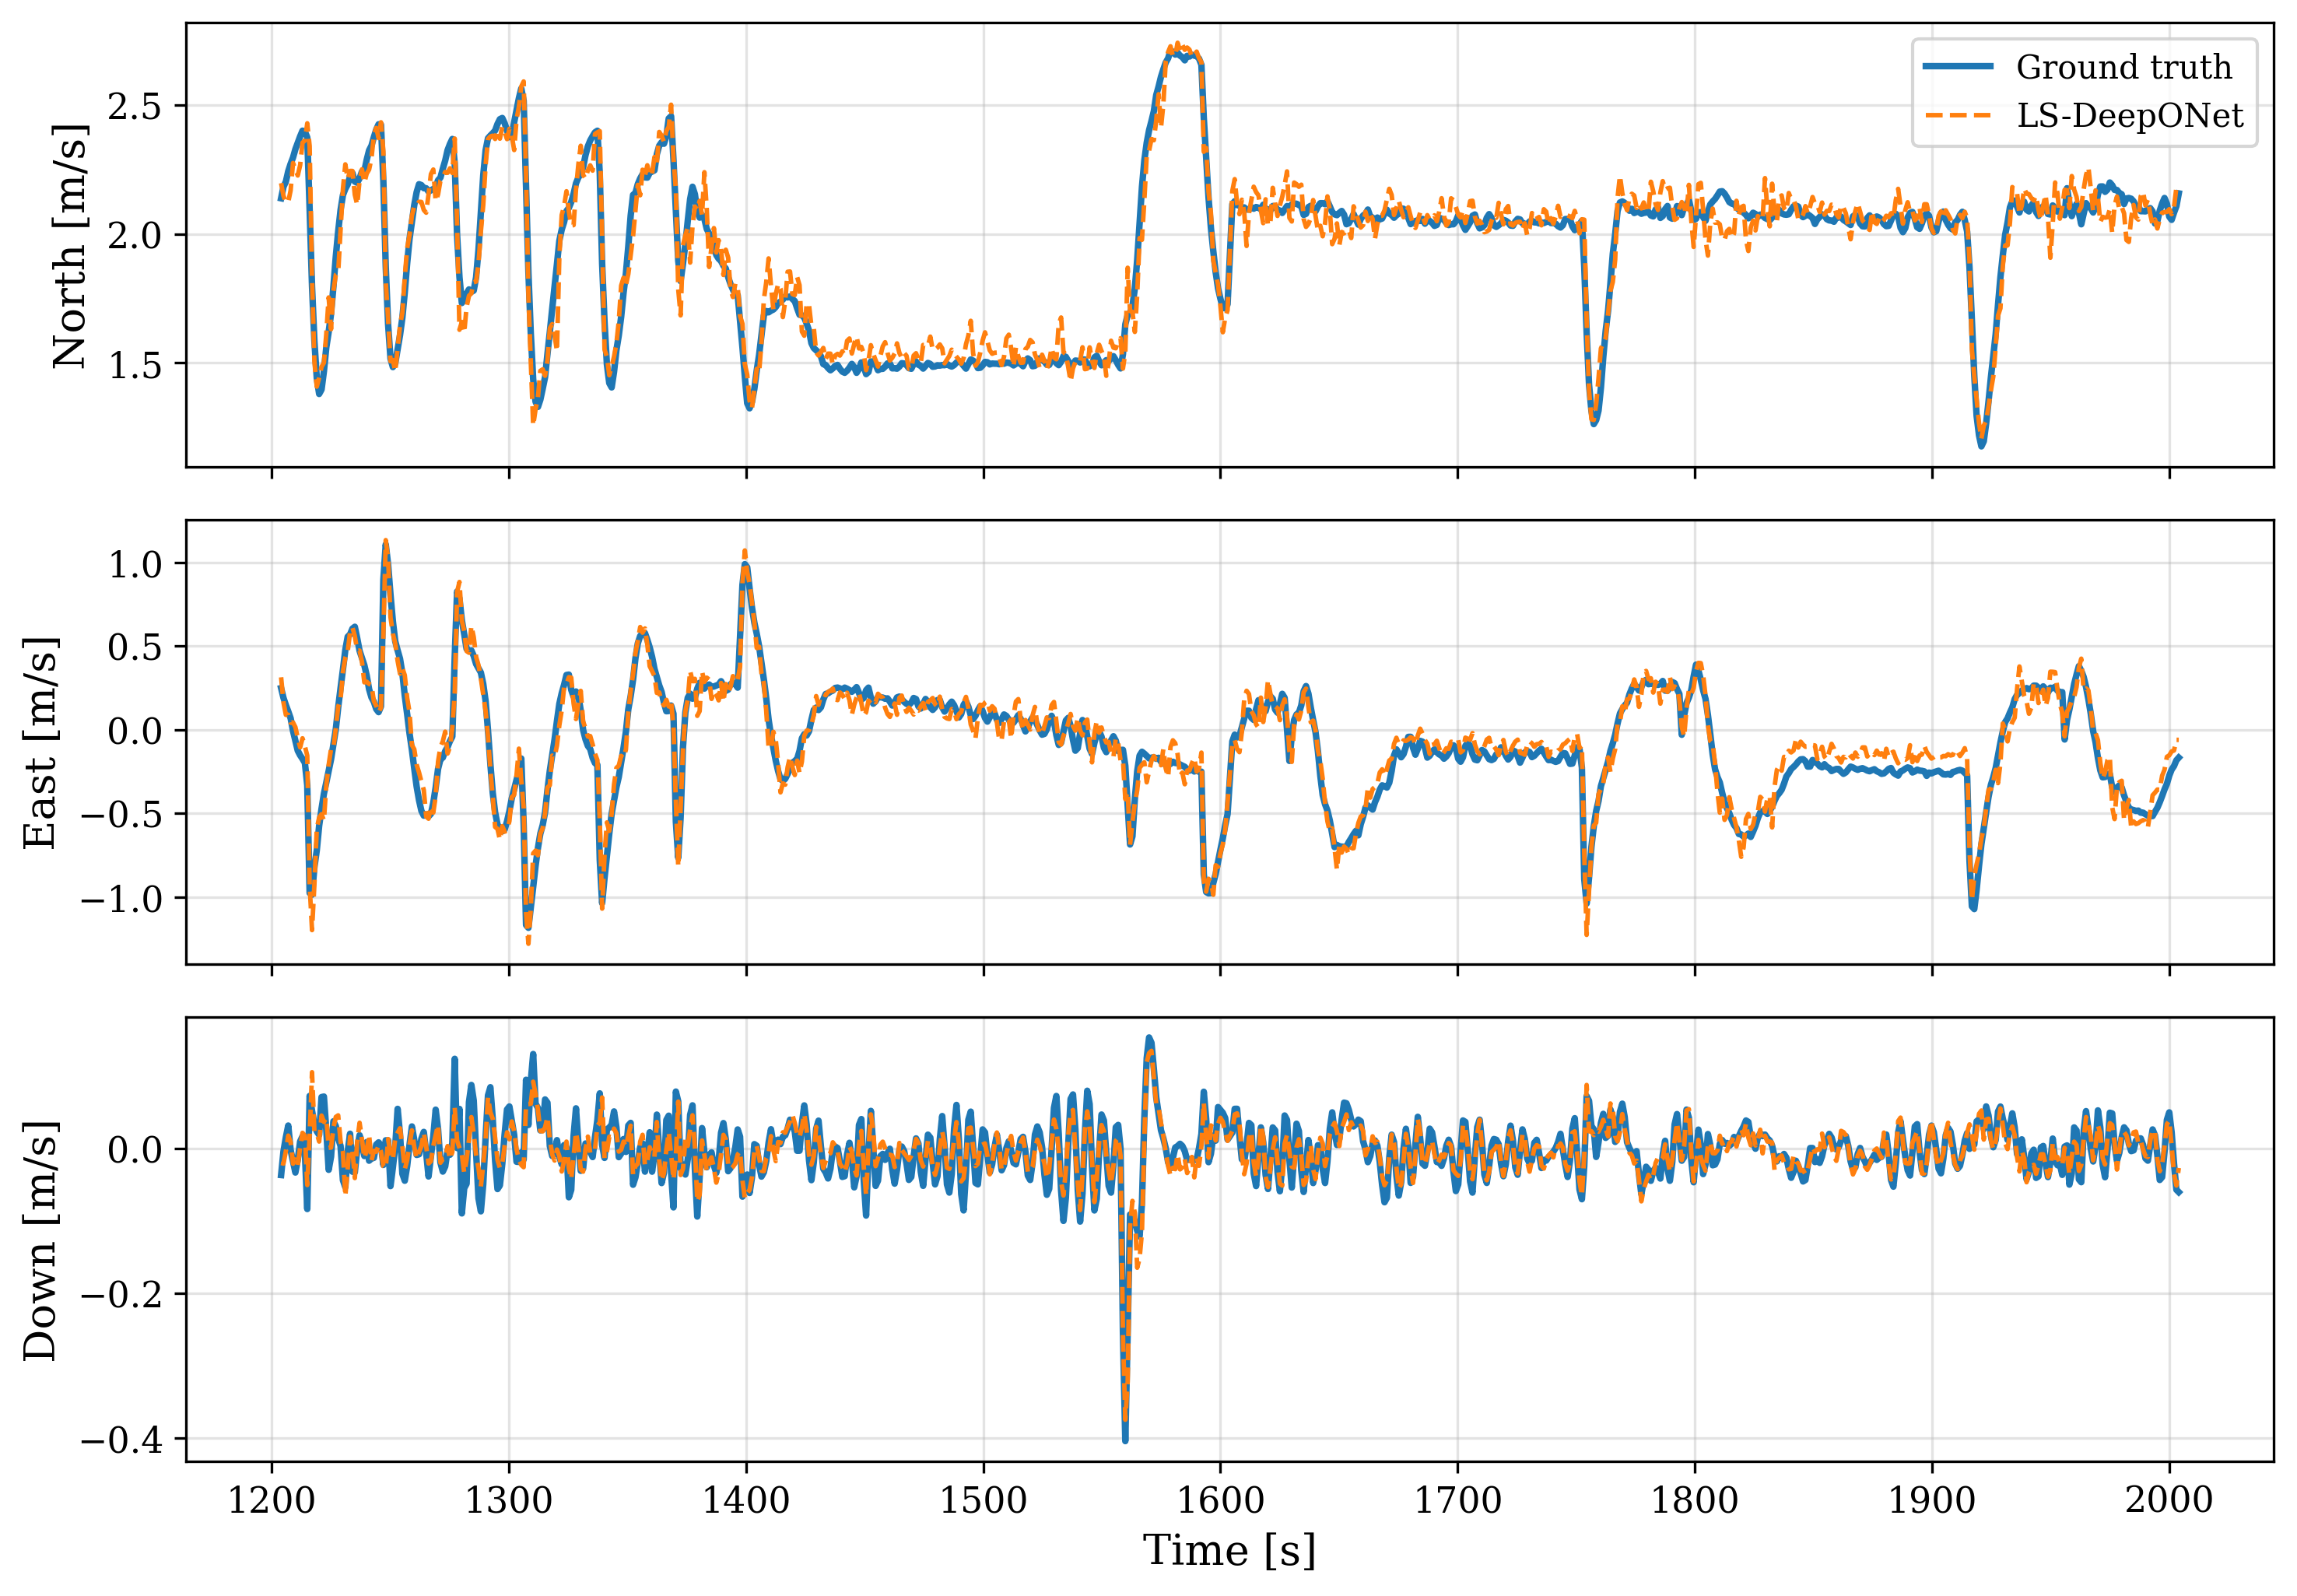

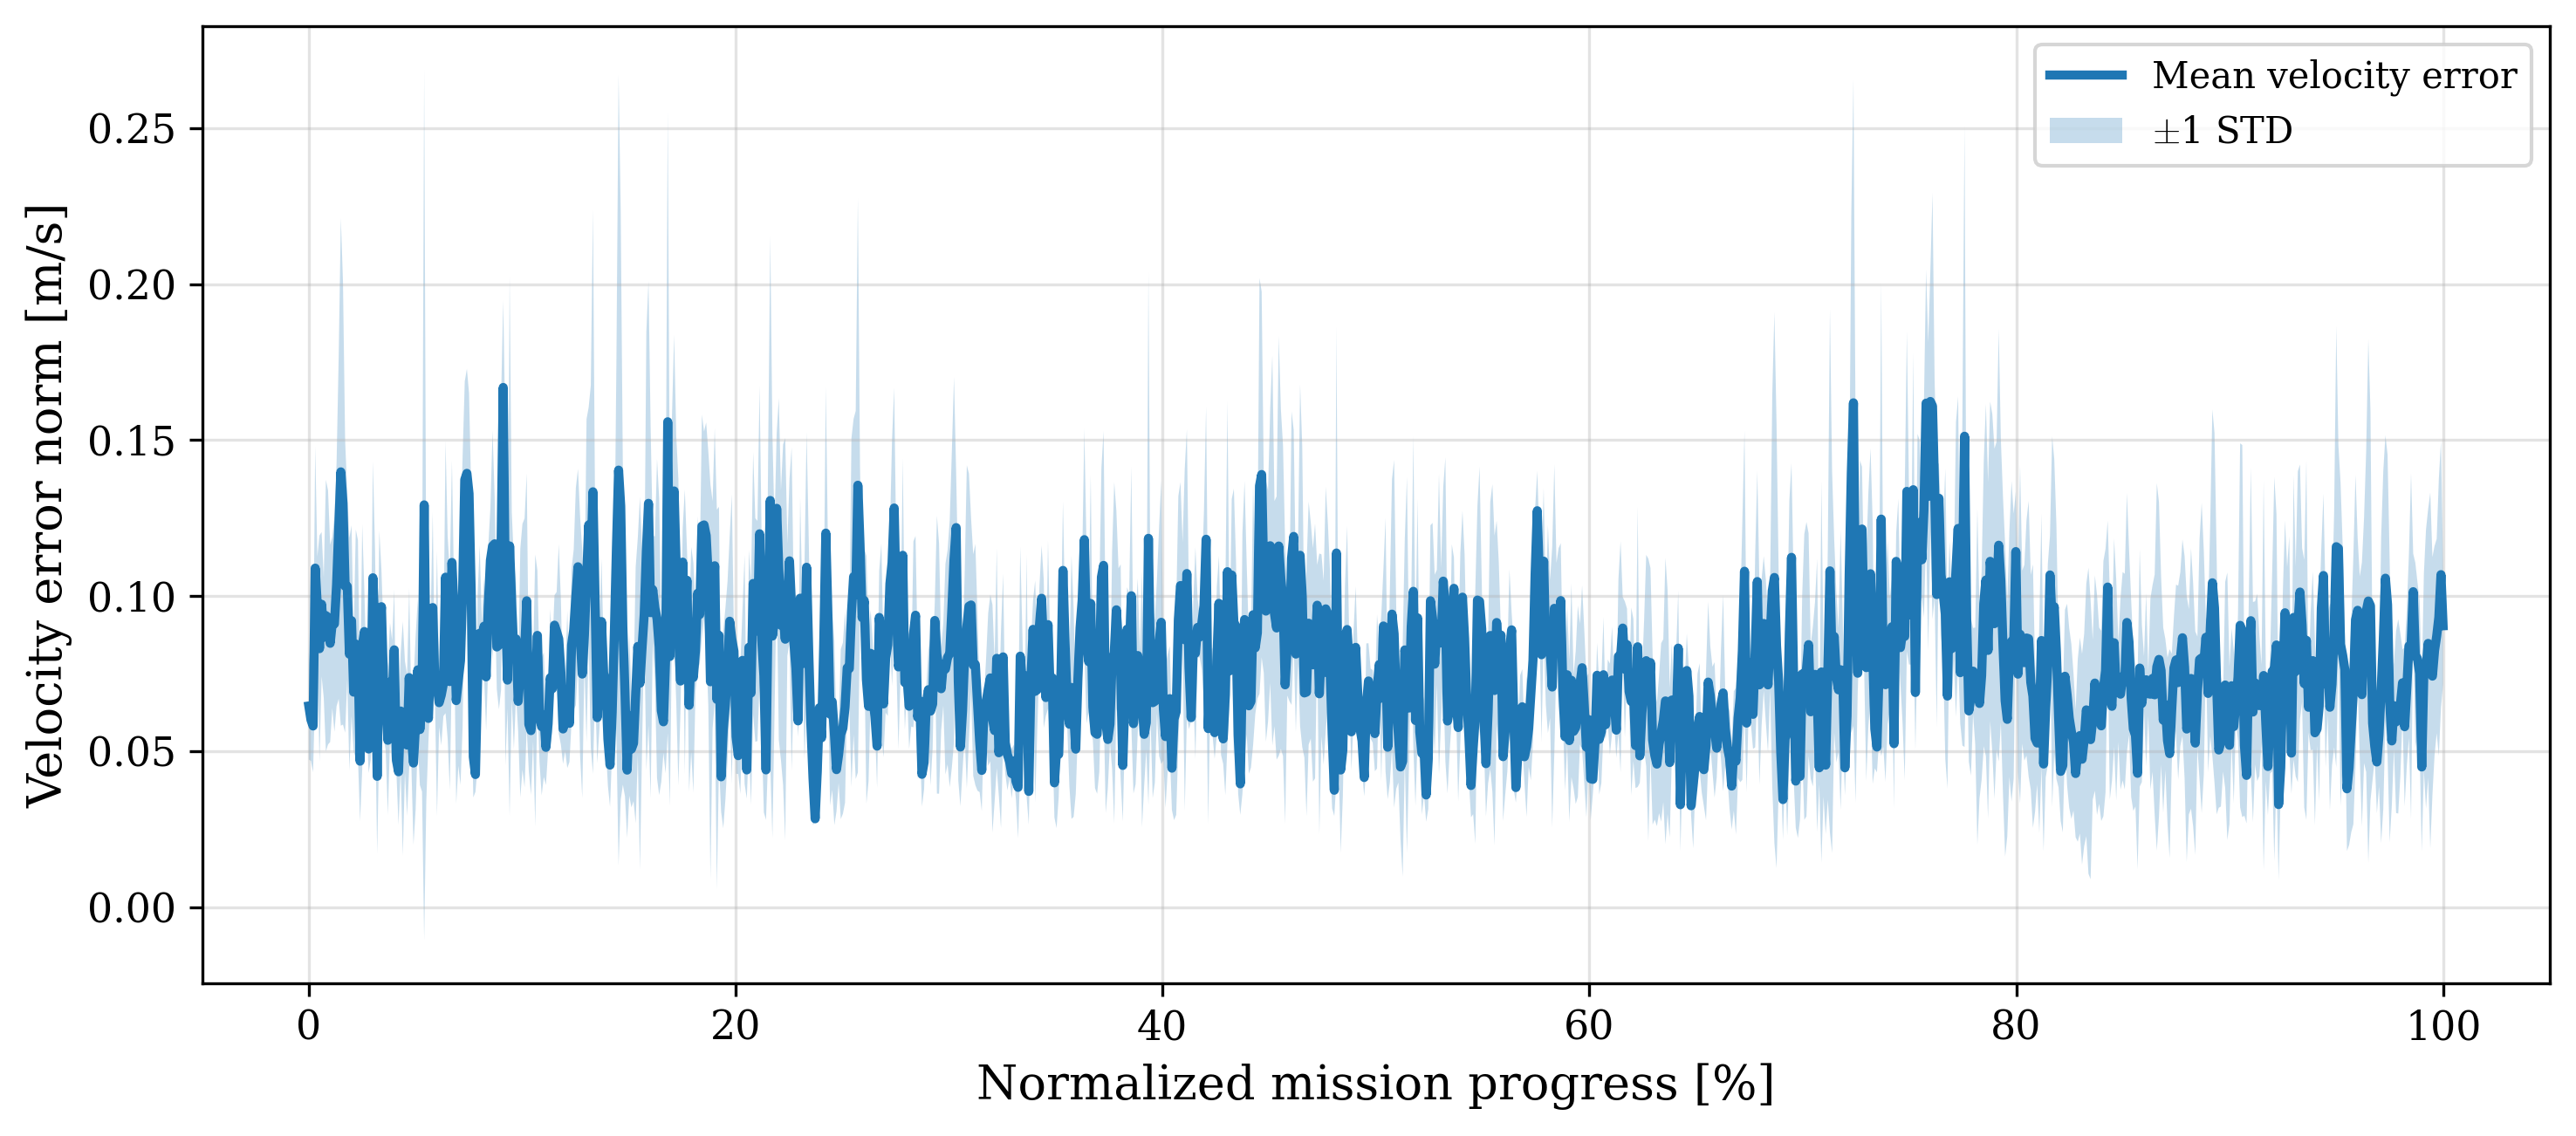

Paper figures saved in: /home/asahoo/DVL/base_paper/figures


In [14]:
# ============================================================
# 13. Paper figures: GT vs predicted velocity and mean error ± STD
# ============================================================

# Publication style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "mathtext.fontset": "cm",
})


def plot_gt_vs_pred_velocity_profile(
    t_sec,
    gt,
    pred,
    filename="gt_vs_pred_velocity_profile_test.png",
    model_name="LS-DeepONet"
):
    axis_labels = ["North", "East", "Down"]

    fig, axes = plt.subplots(3, 1, figsize=(10, 7), dpi=300, sharex=True)

    for i, ax in enumerate(axes):
        ax.plot(t_sec, gt[:, i], linewidth=2.0, label="Ground truth")
        ax.plot(t_sec, pred[:, i], linewidth=1.4, linestyle="--", label=model_name)

        ax.set_ylabel(f"{axis_labels[i]} [m/s]")
        ax.grid(True, alpha=0.35)

    axes[-1].set_xlabel("Time [s]")
    axes[0].legend(loc="best")

    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    fig.savefig(FIG_DIR / filename.replace(".png", ".pdf"), bbox_inches="tight")
    plt.show()


def plot_mean_velocity_error_profile(
    split_predictions,
    split_names=None,
    filename="mean_velocity_error_profile_std.png",
    model_key="pred",
    n_points=1000
):
    """
    Computes velocity error norm for each split/test trajectory,
    interpolates to a normalized mission progress axis,
    and plots mean ± 1 STD.
    """

    if split_names is None:
        split_names = list(split_predictions.keys())

    all_errors = []

    for split_name in split_names:
        values = split_predictions[split_name]

        gt = values["gt"]
        pred = values[model_key]

        err_norm = np.linalg.norm(pred - gt, axis=1)

        x_old = np.linspace(0, 100, len(err_norm))
        x_new = np.linspace(0, 100, n_points)

        err_interp = np.interp(x_new, x_old, err_norm)
        all_errors.append(err_interp)

    all_errors = np.array(all_errors)

    mean_err = np.mean(all_errors, axis=0)
    std_err = np.std(all_errors, axis=0)

    x_axis = np.linspace(0, 100, n_points)

    plt.figure(figsize=(10, 4.5), dpi=300)

    plt.plot(
        x_axis,
        mean_err,
        linewidth=2.5,
        label="Mean velocity error"
    )

    plt.fill_between(
        x_axis,
        mean_err - std_err,
        mean_err + std_err,
        alpha=0.25,
        label=r"$\pm$1 STD"
    )

    plt.xlabel("Normalized mission progress [%]")
    plt.ylabel("Velocity error norm [m/s]")
    plt.grid(True, alpha=0.35)
    plt.legend(loc="best")
    plt.tight_layout()

    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.savefig(FIG_DIR / filename.replace(".png", ".pdf"), bbox_inches="tight")
    plt.show()


# ------------------------------------------------------------
# Figure 1: GT vs Predicted velocity profile for test split
# ------------------------------------------------------------
test_values = split_predictions["test"]

plot_gt_vs_pred_velocity_profile(
    t_sec=test_values["time"],
    gt=test_values["gt"],
    pred=test_values["pred"],
    filename="gt_vs_pred_velocity_profile_test.png",
    model_name="LS-DeepONet"
)


# ------------------------------------------------------------
# Figure 2: Mean velocity error profile ± STD
# If you have multiple splits, it uses all available splits.
# ------------------------------------------------------------
plot_mean_velocity_error_profile(
    split_predictions=split_predictions,
    split_names=list(split_predictions.keys()),
    filename="mean_velocity_error_profile_std.png",
    model_key="pred",
    n_points=1000
)

print("Paper figures saved in:", FIG_DIR.resolve())

In [15]:
# ============================================================
# GT vs Predicted velocity profile for EACH test trajectory
# ============================================================

def plot_gt_vs_pred_single_trajectory(
    t_sec,
    gt,
    pred,
    traj_name,
    filename,
    model_name="LS-DeepONet"
):

    axis_labels = ["North", "East", "Down"]

    fig, axes = plt.subplots(3, 1, figsize=(10, 7),
                             dpi=300,
                             sharex=True)

    for d, ax in enumerate(axes):

        ax.plot(
            t_sec,
            gt[:, d],
            linewidth=2.0,
            label="Ground Truth"
        )

        ax.plot(
            t_sec,
            pred[:, d],
            linestyle="--",
            linewidth=1.5,
            label=model_name
        )

        ax.set_ylabel(f"{axis_labels[d]} [m/s]")
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time [s]")
    axes[0].legend()

    fig.suptitle(traj_name)

    fig.tight_layout()

    plt.savefig(
        FIG_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

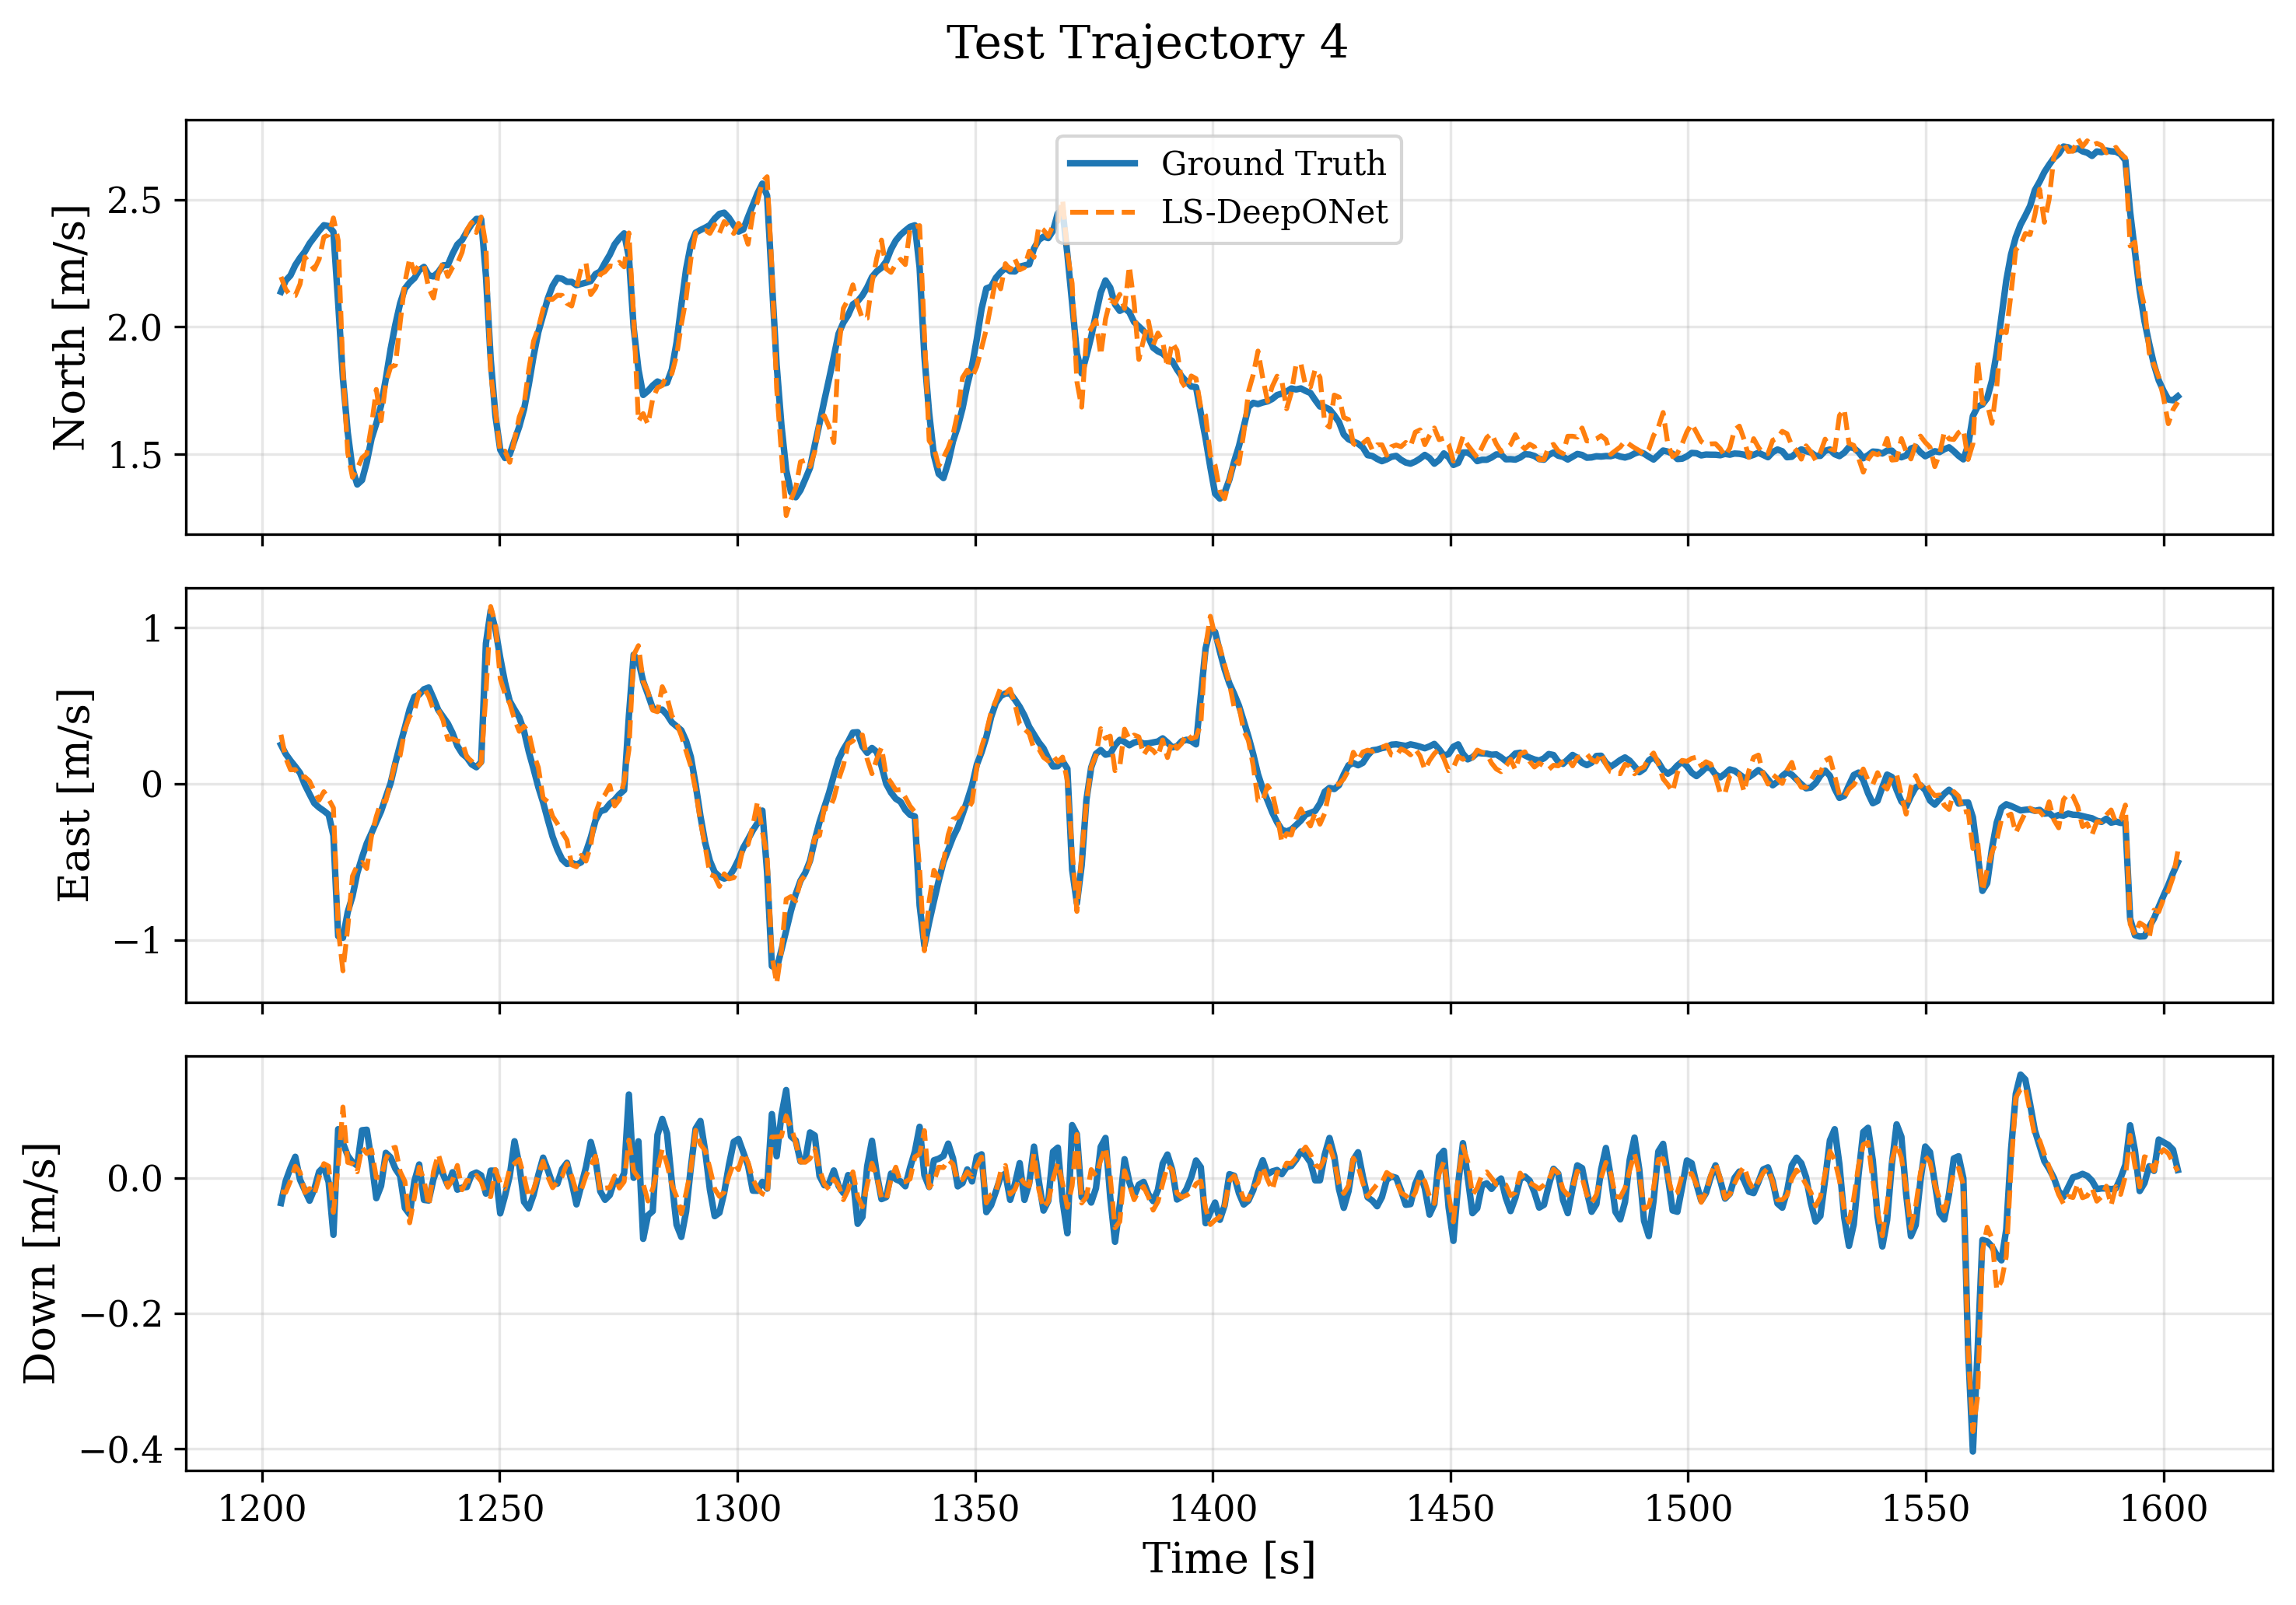

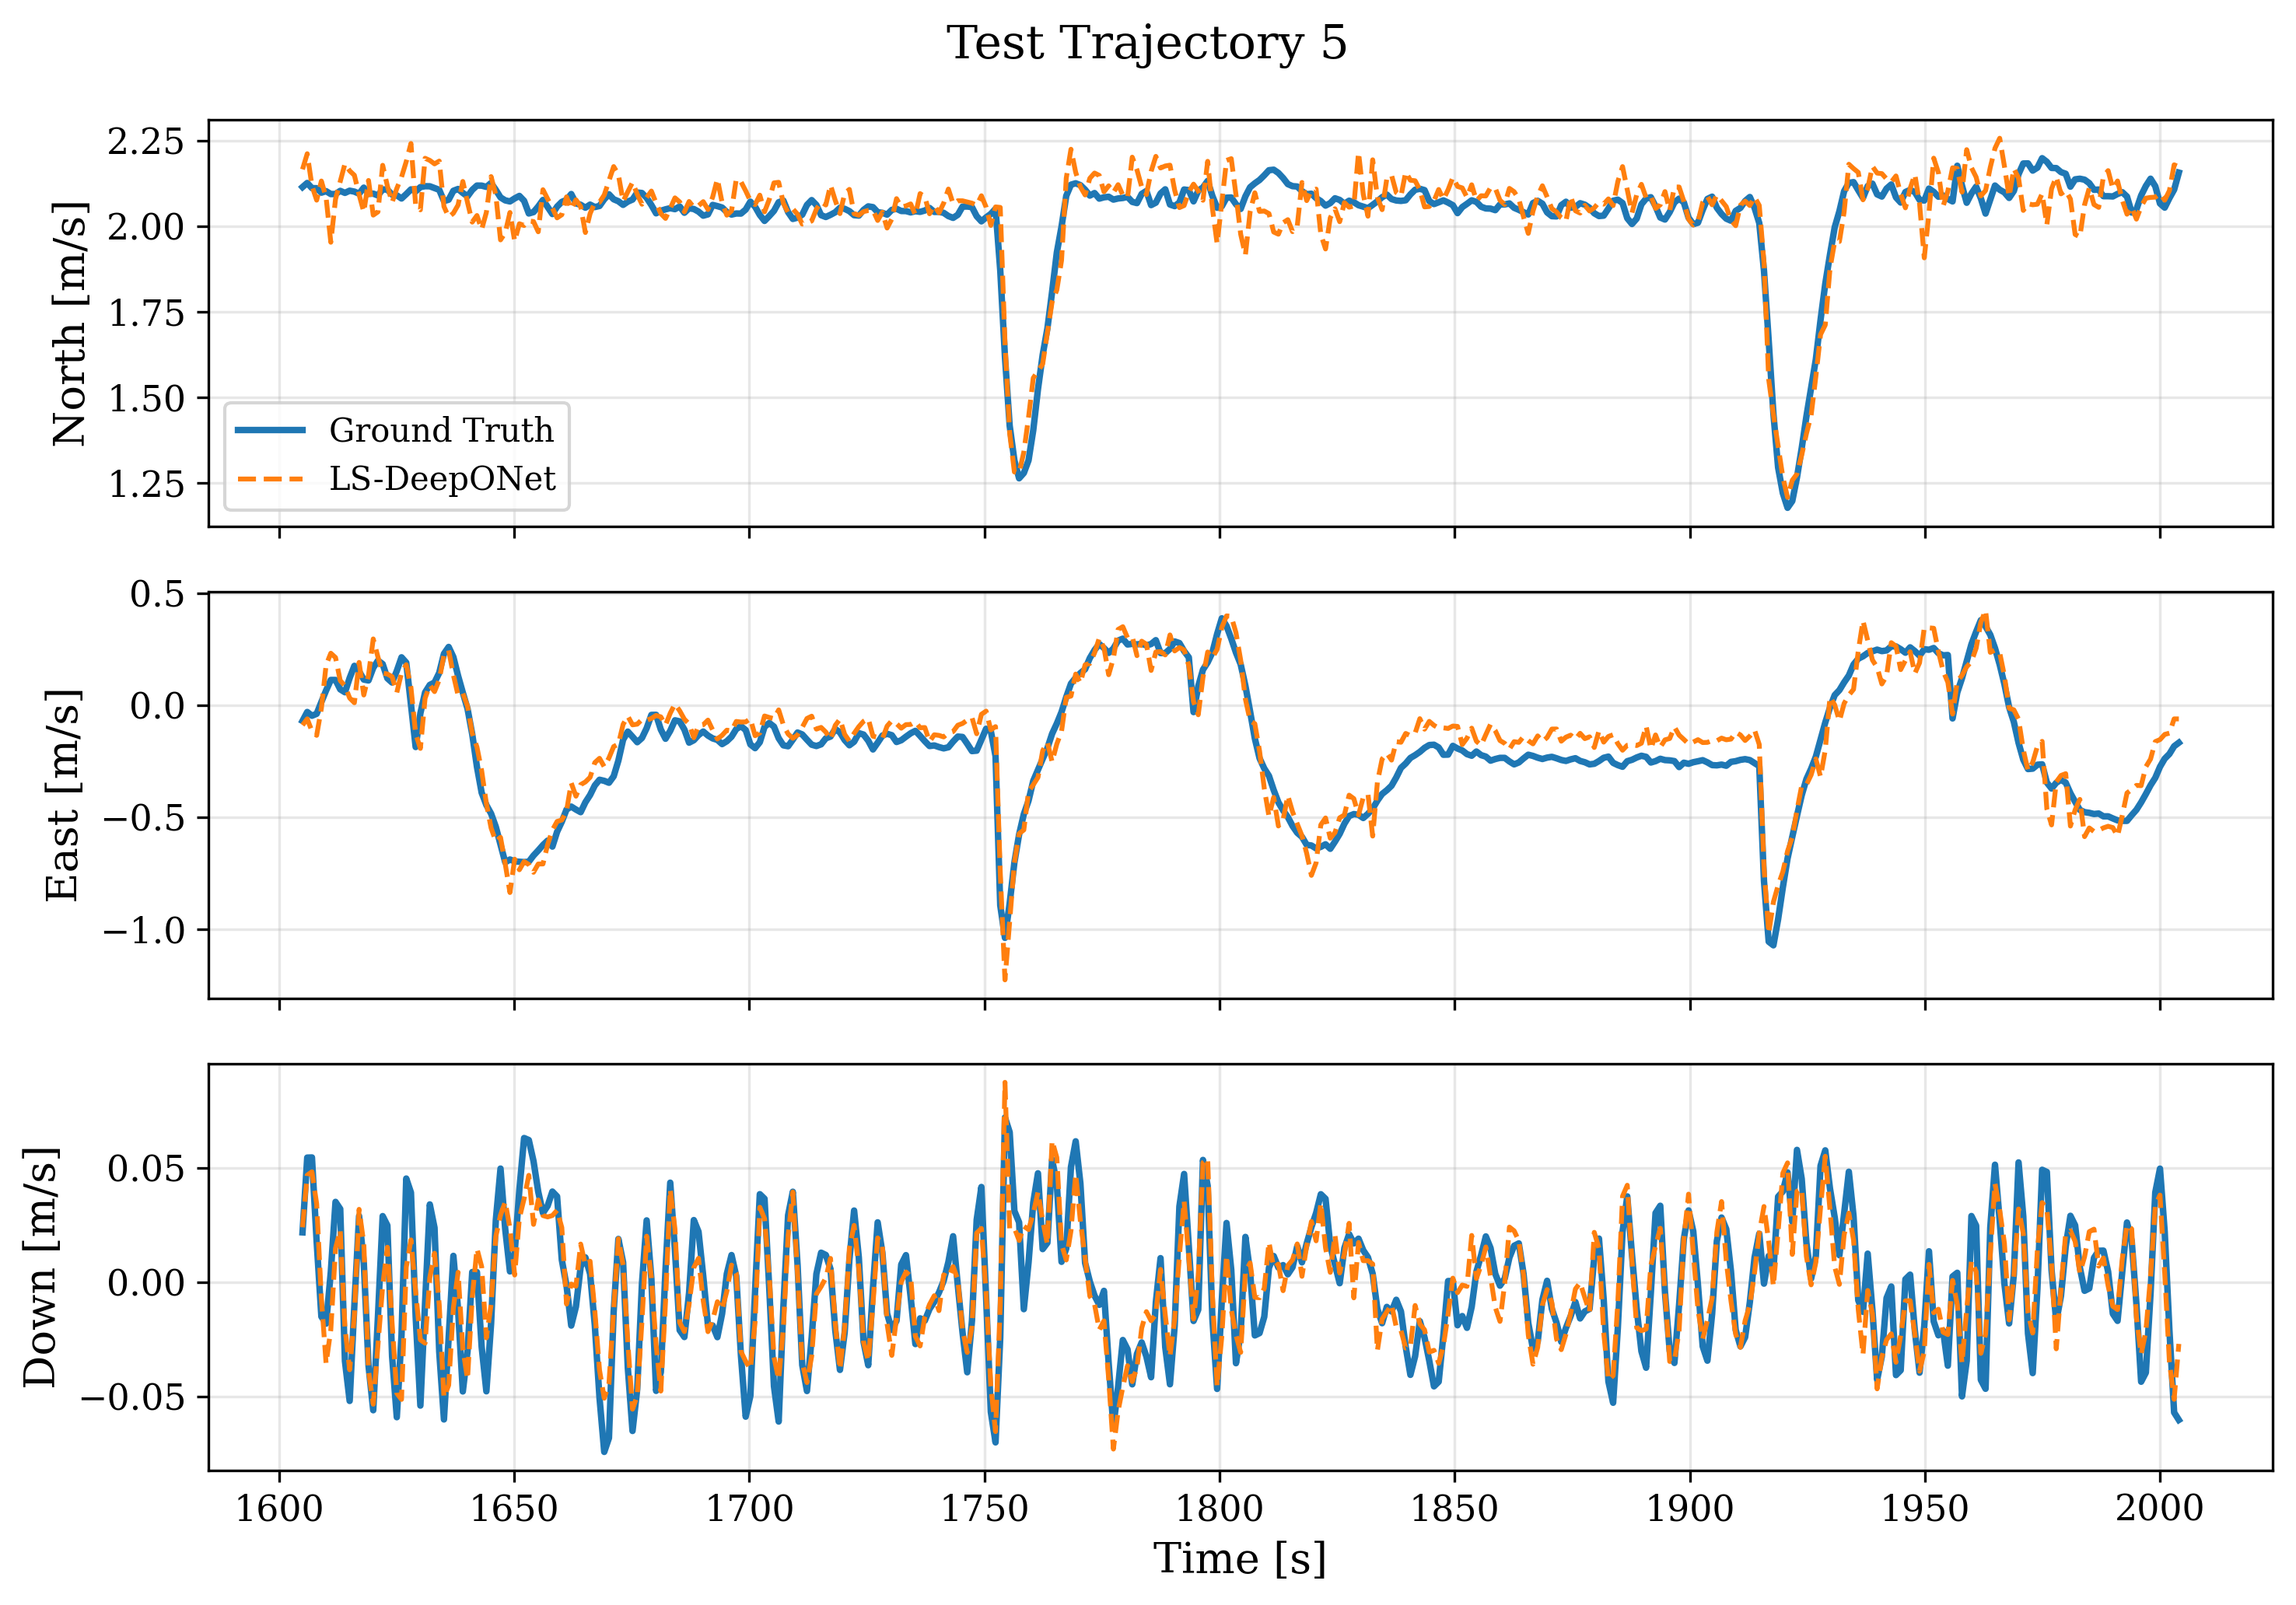

In [16]:
test_values = split_predictions["test"]

traj_ids = test_values["traj_id"]      # trajectory index
time_all = test_values["time"]
gt_all   = test_values["gt"]
pred_all = test_values["pred"]

unique_traj = np.unique(traj_ids)

for traj in unique_traj:

    idx = traj_ids == traj

    plot_gt_vs_pred_single_trajectory(
        t_sec=time_all[idx],
        gt=gt_all[idx],
        pred=pred_all[idx],
        traj_name=f"Test Trajectory {traj}",
        filename=f"velocity_profile_traj_{traj}.png"
    )

## Notes

- IMU is loaded from `A-KIT/AUV_IMU_npy/IMU_trajectory*.npy` with format `[time, ax, ay, az, gx, gy, gz]`.
- The main DeepONet uses IMU linearly interpolated to the 1 Hz DVL timestamps.
- Raw 100 Hz IMU windows are kept only for the BeamsNetV1 baseline, which expects `(N, 3, 100)` accel and gyro inputs.
- This is **DVL+IMU as network input**, not a full inertial navigation filter.
- The velocity KF smooths only `[vx, vy, vz]`; it does not estimate position. Tune `KF_Q_VEL` and `KF_R_VEL` in the KF cell.
- If classical LS is already near-perfect, IMU may not improve much. IMU helps more when DVL beams are noisy, biased, dropped out, or dynamically corrupted.
- `ALPHA_DEG` must match the beam-generation angle in A-KIT. A wrong angle will make the LS baseline and beam-consistency loss misleading.
- The default split uses whole trajectories for train/validation/test. This is harder and more realistic than randomly splitting samples from every trajectory.

- `BeamsNetV1` is included as an additional neural baseline using the architecture and batch size from the provided reference code.

- For 3-fold trajectory cross-validation, set `CV_FOLD = 0`, `1`, or `2` in the split cell and rerun the notebook.
